# Install Libraries


In [ ]:
!pip install -q transformers datasets evaluate accelerate wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00


# Imports + Basic Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import evaluate
import wandb

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

# Check GPU

In [ ]:
!nvidia-smi

Sat Nov 29 17:25:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             55W /  400W |       5MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Paths

In [ ]:
DATA_CSV = "sentiment140-final-fixed.csv"

SAVE_DIR = "distilbert_sentiment140"

os.makedirs(os.path.dirname(SAVE_DIR), exist_ok=True)

DATA_CSV, SAVE_DIR

('/content/drive/MyDrive/sentiment140-final-fixed.csv',
 '/content/drive/MyDrive/distilbert_sentiment140')

In [ ]:
df = pd.read_csv(DATA_CSV)

print("Columns:", df.columns.tolist())
df.head()

Columns: ['target', 'label_str', 'id', 'date', 'flag', 'user', 'text', 'text_clean', 'sentiment_score_norm', 'neg_word_count', 'pos_word_count', 'avg_word_length', 'char_count', 'word_count']


,target,label_str,id,date,flag,user,text,text_clean,sentiment_score_norm,neg_word_count,pos_word_count,avg_word_length,char_count,word_count
0,0,negative,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...,-1,2,0,4,104,21
1,0,negative,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...,0,0,0,3,76,17
2,0,negative,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,0,0,0,3,46,10
3,0,negative,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...,0,0,0,3,85,20
4,0,negative,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,not the whole crew,0,0,0,3,18,4


# Prepare Text + Labels

In [ ]:
# Keep only the necessary columns
df = df[["text_clean", "target"]].dropna()

# Ensure numeric labels
df["target"] = df["target"].astype(int)

# Filter to the three known Sentiment140 classes
df = df[df["target"].isin([0, 2, 4])]

# Map original labels (0,2,4) → (0,1,2)
label_map = {0: 0, 2: 1, 4: 2}
df["label"] = df["target"].map(label_map)

# Rename for HuggingFace
df = df.rename(columns={"text_clean": "text"})

print(df.head())
print("Label counts (internal 0/1/2):")
print(df["label"].value_counts())
print("Total rows:", len(df))

                                                text  target  label
0  is upset that he cant update his facebook by t...       0      0
1  i dived many times for the ball managed to sav...       0      0
2     my whole body feels itchy and like its on fire       0      0
3  no its not behaving at all im mad why am i her...       0      0
4                                 not the whole crew       0      0
Label counts (internal 0/1/2):
label
0    796896
2    796105
Name: count, dtype: int64
Total rows: 1593001


# Train / Validation Splits

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df["label"]
)

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

Train size: 1433700
Val size: 159301


# Tokeniser + Tokenised Datasets

In [ ]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tok = train_ds.map(tokenize, batched=True)
val_tok   = val_ds.map(tokenize, batched=True)

# Keep only model-relevant columns
cols = ["input_ids", "attention_mask", "label"]
train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in cols])
val_tok   = val_tok.remove_columns([c for c in val_tok.column_names if c not in cols])

train_tok.set_format("torch")
val_tok.set_format("torch")

train_tok[0]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/1433700 [00:00<?, ? examples/s]

Map:   0%|          | 0/159301 [00:00<?, ? examples/s]

{'label': tensor(2),
 'input_ids': tensor([  101,  9805,  9397,  9397,  2009,  3084,  2033,  2614,  4795,  2066,
          5665,  3013,  7680,  2487,  2039, 18740,  2017,  2039,  2001,  6342,
         24759,  2863,  9541,  2080,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,   

# Load pre-trained DistilBERT

In [ ]:
id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


# Define MEtrics

In [ ]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    refs = p.label_ids
    return {
        "accuracy": accuracy.compute(predictions=preds, references=refs)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=refs, average="macro")["f1"]
    }

# Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_output",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2,      # increase to 3–4 later if training is fast
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    report_to=["wandb"],     # log to wandb
    run_name="distilbert-sentiment140"
)

training_args

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.NO,
eval_use_gather_object=False,
f

# WandB Login + Config

In [ ]:
import wandb
wandb.api.default_entity

'pramod21-university-of-maryland'

In [ ]:
# Login (first time will prompt in the cell)
wandb.login()

WANDB_PROJECT = "sentiment140-bert"
WANDB_ENTITY  = "pramod21-university-of-maryland"

# Initialize WandB Run + Trainer + Train

In [ ]:
run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="distilbert-sentiment140",
    config={
        "model_name": MODEL_NAME,
        "num_train_epochs": training_args.num_train_epochs,
        "batch_size": training_args.per_device_train_batch_size,
        "max_length": 128,
        "dataset_size": len(df)
    }
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

/tmp/ipython-input-1013228290.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
100,0.651000
200,0.492400
300,0.456700
400,0.453000
500,0.468000
600,0.449700
700,0.448800
800,0.430300
900,0.422100
1000,0.426300


TrainOutput(global_step=89608, training_loss=0.3285246576680508, metrics={'train_runtime': 7617.5335, 'train_samples_per_second': 376.421, 'train_steps_per_second': 11.763, 'total_flos': 9.49609481900544e+16, 'train_loss': 0.3285246576680508, 'epoch': 2.0})

# Evaluate on validation set + log metrics to wandb

In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

wandb.log({
    "eval_loss": eval_results.get("eval_loss"),
    "eval_accuracy": eval_results.get("eval_accuracy"),
    "eval_f1_macro": eval_results.get("eval_f1_macro")
})

{'eval_loss': 0.33016785979270935, 'eval_accuracy': 0.8596367882185297, 'eval_f1_macro': 0.8596066762651535, 'eval_runtime': 138.9882, 'eval_samples_per_second': 1146.148, 'eval_steps_per_second': 17.915, 'epoch': 2.0}


# Confusion matrix + histograms (and log to wandb)

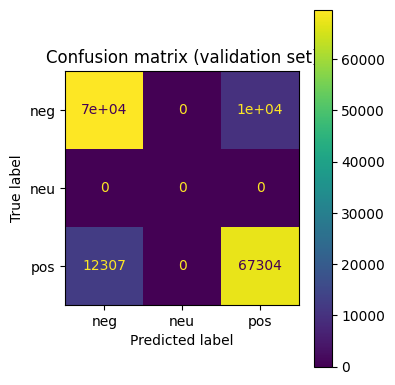

In [ ]:
preds = trainer.predict(val_tok)
y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
disp = ConfusionMatrixDisplay(cm, display_labels=["neg","neu","pos"])

fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax)
plt.title("Confusion matrix (validation set)")
plt.tight_layout()

wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.show()

# Optional: log distributions
wandb.log({
    "val_label_distribution": wandb.Histogram(y_true),
    "val_pred_distribution": wandb.Histogram(y_pred)
})

# save model + tokeniser to google drive

In [ ]:
# Save model + tokenizer to Drive
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("Model and tokenizer saved to:", SAVE_DIR)

# Optional: log as a model artifact in wandb
artifact = wandb.Artifact("distilbert-sentiment140", type="model")
artifact.add_dir(SAVE_DIR)
wandb.log_artifact(artifact)

wandb.finish()

wandb: Adding directory to artifact (/content/drive/MyDrive/distilbert_sentiment140)... 

Model and tokenizer saved to: /content/drive/MyDrive/distilbert_sentiment140


Done. 0.9s


eval/accuracy,▁
eval/f1_macro,▁
eval/loss,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
eval_accuracy,▁
eval_f1_macro,▁
eval_loss,▁
test/accuracy,▁
+10,...


In [ ]:
import os
os.listdir("./bert_output")

['checkpoint-22000',
 'checkpoint-25500',
 'checkpoint-86500',
 'checkpoint-87000',
 'checkpoint-63000',
 'checkpoint-76000',
 'checkpoint-41000',
 'checkpoint-84500',
 'checkpoint-34000',
 'checkpoint-57500',
 'checkpoint-62000',
 'checkpoint-70500',
 'checkpoint-80500',
 'checkpoint-28500',
 'checkpoint-66000',
 'checkpoint-40500',
 'checkpoint-33500',
 'checkpoint-75000',
 'checkpoint-30000',
 'checkpoint-65500',
 'checkpoint-79000',
 'checkpoint-45000',
 'checkpoint-82000',
 'checkpoint-53500',
 'checkpoint-38000',
 'checkpoint-10000',
 'checkpoint-73500',
 'checkpoint-36000',
 'checkpoint-82500',
 'checkpoint-17000',
 'checkpoint-47000',
 'checkpoint-55500',
 'checkpoint-31000',
 'checkpoint-83000',
 'checkpoint-74000',
 'checkpoint-78500',
 'checkpoint-78000',
 'checkpoint-87500',
 'checkpoint-11500',
 'checkpoint-19000',
 'checkpoint-67000',
 'checkpoint-48000',
 'checkpoint-85000',
 'checkpoint-58500',
 'checkpoint-23000',
 'checkpoint-12500',
 'checkpoint-52000',
 'checkpoint-